# PDE vs ODE Comparison

Validate the ODE approximation by comparing against the exact PDE solution
across the parameter ranges used in the sensitivity analysis.

**Compute phase** (cells 1-3): Run PDE solves in parallel, save to `data/pde_comparison/`.
Skip these cells after the first run — all subsequent cells load from disk.

**Analysis phase** (cells 4+): Load cached results and produce figures/tables.

In [14]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
from scipy.stats import spearmanr

from src.pde_comparison import (
    PARAM_LABELS, NOMINAL, RANGES, N_PARAMS,
    QOI_NAMES, QOI_LABELS, N_QOIS,
    build_modified_params_2ccy, evaluate_ode_qois, pde_extract_qois,
    run_single_pde, _init_worker,
    generate_oat_configs, generate_lhs_configs,
    Y_MAX, DY, PDE_N_STEPS,
)
from src import (
    build_paper_example_params, restrict_currencies,
    run_multicurrency_mm, BP,
)

SAVE_DIR = "data/pde_comparison"
N_WORKERS = 10

In [2]:
oat_configs = generate_oat_configs()
lhs_configs = generate_lhs_configs(n_samples=20, seed=42)
all_configs = oat_configs + lhs_configs

print(f"OAT configs: {len(oat_configs)} (1 nominal + {N_PARAMS} params x 2 edges)")
print(f"LHS configs: {len(lhs_configs)}")
print(f"Total PDE solves: {len(all_configs)}")

OAT configs: 17 (1 nominal + 8 params x 2 edges)
LHS configs: 20
Total PDE solves: 37


In [3]:
os.makedirs(os.path.join(SAVE_DIR, "oat"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "lhs"), exist_ok=True)

t0 = time.time()

# Use imap_unordered for tqdm progress tracking
from tqdm.notebook import tqdm

with Pool(processes=N_WORKERS, initializer=_init_worker) as pool:
    results = []
    for res in tqdm(pool.imap_unordered(run_single_pde, all_configs),
                    total=len(all_configs), desc="PDE solves"):
        results.append(res)
        
        # Save each result immediately
        name = res['name']
        subdir = "lhs" if name.startswith("lhs_") else "oat"
        np.savez_compressed(
            os.path.join(SAVE_DIR, subdir, f"{name}.npz"),
            theta_0=res['theta_0'],
            ode_qois=res['ode_qois'],
            pde_qois=res['pde_qois'],
            params=res['params'],
        )

elapsed = time.time() - t0
print(f"\nCompleted {len(results)} PDE solves in {elapsed/60:.1f} min")
print(f"Average: {elapsed/len(results):.0f} s/solve")

# Save metadata
meta = {
    "n_oat": len(oat_configs),
    "n_lhs": len(lhs_configs),
    "Y_MAX": Y_MAX,
    "DY": DY,
    "PDE_N_STEPS": PDE_N_STEPS,
    "PARAM_LABELS": PARAM_LABELS,
    "QOI_NAMES": QOI_NAMES,
    "NOMINAL": NOMINAL.tolist(),
    "RANGES": RANGES.tolist(),
    "elapsed_seconds": elapsed,
    "n_workers": N_WORKERS,
}
with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved to {SAVE_DIR}/")

PDE solves:   0%|          | 0/37 [00:00<?, ?it/s]

HJB PDE solve (implicit):   5%|▌         | 1/20 [00:18<05:51, 18.49s/step]]]/Users/sebastianapelgren/code/optimal-market-making-eFX/src/hamiltonian.py:27: RuntimeWarning: divide by zero encountered in log
  w = np.where(big, np.where(np.isinf(x), x, np.log(x)), w)
HJB PDE solve (implicit):  55%|█████▌    | 11/20 [01:19<00:48,  5.40s/step]/Users/sebastianapelgren/code/optimal-market-making-eFX/src/hamiltonian.py:27: RuntimeWarning: divide by zero encountered in log
  w = np.where(big, np.where(np.isinf(x), x, np.log(x)), w)
HJB PDE solve (implicit):  95%|█████████▌| 19/20 [30:44<01:42, 102.51s/step]


Completed 37 PDE solves in 65.6 min
Average: 106 s/solve
Saved to data/pde_comparison/


HJB PDE solve (implicit): 100%|██████████| 20/20 [32:19<00:00, 97.00s/step] 


In [4]:
# Load all results from disk
def load_results(save_dir):
    """Load all .npz files from oat/ and lhs/ subdirs."""
    oat = {}
    for fn in sorted(os.listdir(os.path.join(save_dir, "oat"))):
        if fn.endswith(".npz"):
            name = fn[:-4]
            data = np.load(os.path.join(save_dir, "oat", fn))
            oat[name] = {k: data[k] for k in data.files}
    lhs = {}
    for fn in sorted(os.listdir(os.path.join(save_dir, "lhs"))):
        if fn.endswith(".npz"):
            name = fn[:-4]
            data = np.load(os.path.join(save_dir, "lhs", fn))
            lhs[name] = {k: data[k] for k in data.files}
    return oat, lhs

oat_data, lhs_data = load_results(SAVE_DIR)
print(f"Loaded {len(oat_data)} OAT + {len(lhs_data)} LHS results")

Loaded 17 OAT + 20 LHS results


## Analysis

### Summary error table

In [15]:
# Build arrays: (n_configs, n_qois) for ODE and PDE
def error_table(data_dict, title):
    """Print error table for a set of configs."""
    print(f"\n{title}")
    print(f"{'Config':>20s}", end="")
    for q in range(N_QOIS):
        print(f"  {QOI_NAMES[q]:>18s}", end="")
    print()
    print(f"{'':>20s}", end="")
    for q in range(N_QOIS):
        print(f"  {'rel err':>18s}", end="")
    print()
    print("-" * (20 + N_QOIS * 20))
    
    for name in sorted(data_dict.keys()):
        d = data_dict[name]
        ode = d['ode_qois']
        pde = d['pde_qois']
        print(f"{name:>20s}", end="")
        for q in range(N_QOIS):
            rel = abs(ode[q] - pde[q]) / (abs(pde[q]) + 1e-30)
            print(f"  {rel:18.2e}", end="")
        print()

error_table(oat_data, "OAT Configurations")

# Summary statistics
print("\n\nSummary across OAT configs:")
print(f"{'QoI':>20s}  {'max rel err':>12s}  {'mean rel err':>12s}  {'max abs err':>12s}")
for q in range(N_QOIS):
    rel_errs = []
    abs_errs = []
    for d in oat_data.values():
        ode, pde = d['ode_qois'][q], d['pde_qois'][q]
        rel_errs.append(abs(ode - pde) / (abs(pde) + 1e-30))
        abs_errs.append(abs(ode - pde))
    print(f"{QOI_NAMES[q]:>20s}  {max(rel_errs):12.2e}  {np.mean(rel_errs):12.2e}  {max(abs_errs):12.4f}")


OAT Configurations
              Config    tier_spread_diff        own_inv_skew          hedge_rate         net_revenue      neutral_spread
                                 rel err             rel err             rel err             rel err             rel err
------------------------------------------------------------------------------------------------------------------------
        alpha_1_high            8.03e-04            9.43e-02            3.66e-01            8.90e-02            5.31e-03
         alpha_1_low            2.25e-04            5.23e-02            1.49e-01            5.01e-02            3.03e-04
        alpha_2_high            1.59e-03            3.35e-02            1.43e-01            3.15e-02            2.68e-03
         alpha_2_low            2.47e-04            1.73e-02            9.58e-02            3.65e-03            1.42e-03
         beta_1_high            6.79e-04            1.10e-01            4.68e-01            8.85e-02            2.96e-03
          be

### Sensitivity rankings and Spearman rho

In [16]:
# OAT sensitivity: |QoI(high) - QoI(low)| for each parameter
def compute_oat_sensitivities(data):
    """Compute OAT sensitivity magnitudes for ODE and PDE."""
    ode_sens = np.zeros((N_PARAMS, N_QOIS))
    pde_sens = np.zeros((N_PARAMS, N_QOIS))
    
    for i, label in enumerate(PARAM_LABELS):
        lo_key = f"{label}_low"
        hi_key = f"{label}_high"
        if lo_key in data and hi_key in data:
            ode_sens[i] = np.abs(data[hi_key]['ode_qois'] - data[lo_key]['ode_qois'])
            pde_sens[i] = np.abs(data[hi_key]['pde_qois'] - data[lo_key]['pde_qois'])
    
    return ode_sens, pde_sens

ode_sens, pde_sens = compute_oat_sensitivities(oat_data)

# Rankings
print("Sensitivity rankings (1 = most sensitive):\n")
for q in range(N_QOIS):
    ode_rank = np.argsort(-ode_sens[:, q]) + 1  # descending
    pde_rank = np.argsort(-pde_sens[:, q]) + 1
    
    # Convert to rank arrays
    ode_ranks = np.empty(N_PARAMS, dtype=int)
    pde_ranks = np.empty(N_PARAMS, dtype=int)
    ode_ranks[np.argsort(-ode_sens[:, q])] = np.arange(1, N_PARAMS + 1)
    pde_ranks[np.argsort(-pde_sens[:, q])] = np.arange(1, N_PARAMS + 1)
    
    rho, pval = spearmanr(ode_sens[:, q], pde_sens[:, q])
    
    print(f"{QOI_LABELS[q]}  (Spearman rho = {rho:.3f}, p = {pval:.3g})")
    print(f"  {'Parameter':>15s}  {'ODE rank':>10s}  {'PDE rank':>10s}  {'ODE mag':>12s}  {'PDE mag':>12s}")
    for i in np.argsort(-ode_sens[:, q]):
        print(f"  {PARAM_LABELS[i]:>15s}  {ode_ranks[i]:>10d}  {pde_ranks[i]:>10d}  "
              f"{ode_sens[i, q]:12.4g}  {pde_sens[i, q]:12.4g}")
    print()

Sensitivity rankings (1 = most sensitive):

$\delta^*_1(0) - \delta^*_2(0)$ [bps]  (Spearman rho = 1.000, p = 0)
        Parameter    ODE rank    PDE rank       ODE mag       PDE mag
           beta_2           1           1        0.2545        0.2544
           beta_1           2           2        0.1164        0.1165
          alpha_2           3           3       0.08773       0.08752
          alpha_1           4           4        0.0513       0.05145
            gamma           5           5      0.001451       0.00156
        sigma_EUR           6           6      0.001235      0.001346
     lambda_scale           7           7      0.001224      0.001228
              eta           8           8             0     3.999e-05

$\delta^*(10) - \delta^*(0)$ [bps]  (Spearman rho = 0.667, p = 0.071)
        Parameter    ODE rank    PDE rank       ODE mag       PDE mag
            gamma           1           1        0.1117        0.1027
     lambda_scale           2           3     

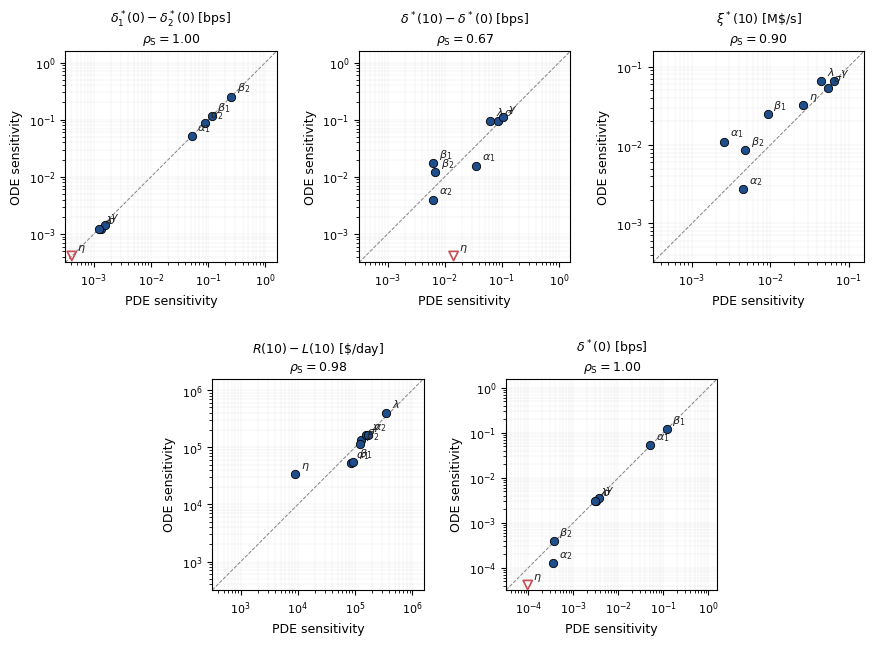

In [17]:
# Sensitivity ranking figure: OAT sensitivity magnitudes, ODE vs PDE, log axes.
# Also defines shared plotting helpers (PANEL_TITLES, QOI_SCALE, colors,
# _make_3_2_gridspec) used by the parity and LHS boxplot cells below.
from matplotlib.gridspec import GridSpec

DAY = 86400.0

PANEL_TITLES = {
    "tier_spread_diff": r"$\delta^*_1(0) - \delta^*_2(0)$ [bps]",
    "own_inv_skew":     r"$\delta^*(10) - \delta^*(0)$ [bps]",
    "hedge_rate":       r"$\xi^*(10)$ [M\$/s]",
    "net_revenue":      r"$R(10) - L(10)$ [\$/day]",
    "neutral_spread":   r"$\delta^*(0)$ [bps]",
}
QOI_SCALE = {
    "tier_spread_diff": 1.0,
    "own_inv_skew":     1.0,
    "hedge_rate":       1.0 / DAY,
    "net_revenue":      1.0,
    "neutral_spread":   1.0,
}
PARAM_TEX = {
    "sigma_EUR":    r"$\sigma$",
    "gamma":        r"$\gamma$",
    "lambda_scale": r"$\lambda$",
    "alpha_1":      r"$\alpha_1$",
    "alpha_2":      r"$\alpha_2$",
    "beta_1":       r"$\beta_1$",
    "beta_2":       r"$\beta_2$",
    "eta":          r"$\eta$",
}

NAVY, CORAL, GOLD = "#1f4e8c", "#c44e52", "gold"

def _make_3_2_gridspec(fig):
    gs = GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.85)
    return [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]

# Compute OAT sensitivity magnitudes with unit scaling
ode_s = np.zeros((N_PARAMS, N_QOIS))
pde_s = np.zeros((N_PARAMS, N_QOIS))
for i, label in enumerate(PARAM_LABELS):
    lo_k, hi_k = f"{label}_low", f"{label}_high"
    for q, qname in enumerate(QOI_NAMES):
        s = QOI_SCALE[qname]
        ode_s[i, q] = abs(oat_data[hi_k]["ode_qois"][q] - oat_data[lo_k]["ode_qois"][q]) * s
        pde_s[i, q] = abs(oat_data[hi_k]["pde_qois"][q] - oat_data[lo_k]["pde_qois"][q]) * s

plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

os.makedirs("report/figures", exist_ok=True)
fig = plt.figure(figsize=(10.5, 7.0))
axes = _make_3_2_gridspec(fig)

for q, ax in enumerate(axes):
    ode = ode_s[:, q].copy()
    pde = pde_s[:, q].copy()

    nonzero_mask = (ode > 0) & (pde > 0)
    nz_vals = np.concatenate([ode[nonzero_mask], pde[nonzero_mask]])
    ax_lo = 10 ** (np.floor(np.log10(nz_vals.min())) - 0.5)
    ax_hi = 10 ** (np.ceil(np.log10(nz_vals.max())) + 0.2)
    floor = ax_lo * 1.3
    ode_plot = np.maximum(ode, floor)
    pde_plot = np.maximum(pde, floor)

    ax.plot([ax_lo, ax_hi], [ax_lo, ax_hi],
            color="k", linestyle="--", linewidth=0.7, alpha=0.5, zorder=1)
    clip_mask = (ode == 0) | (pde == 0)
    ax.scatter(pde_plot[~clip_mask], ode_plot[~clip_mask],
               s=36, facecolors=NAVY, edgecolors="k",
               linewidths=0.6, zorder=3)
    ax.scatter(pde_plot[clip_mask], ode_plot[clip_mask],
               s=44, marker="v", facecolors="none",
               edgecolors=CORAL, linewidths=1.2, zorder=3)
    for i, label in enumerate(PARAM_LABELS):
        ax.annotate(PARAM_TEX[label], (pde_plot[i], ode_plot[i]),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=8, color="#222222")
    rho, _ = spearmanr(ode, pde)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(ax_lo, ax_hi)
    ax.set_ylim(ax_lo, ax_hi)
    ax.set_aspect("equal")
    ax.grid(True, which="both", linewidth=0.3, alpha=0.3)
    ax.set_xlabel("PDE sensitivity")
    ax.set_ylabel("ODE sensitivity")
    ax.set_title(f"{PANEL_TITLES[QOI_NAMES[q]]}\n" + r"$\rho_{\mathrm{S}} = " + f"{rho:.2f}$",
                 fontsize=9)

plt.savefig("report/figures/fig_pde_sens_ranking.pdf", bbox_inches="tight")
plt.show()

### Parity plots (ODE vs PDE)

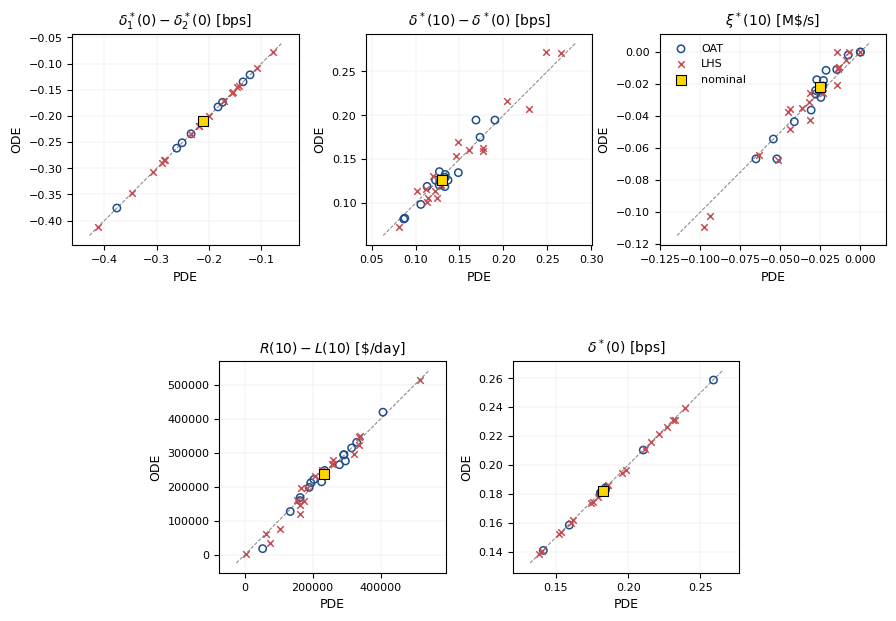

In [18]:
# Parity plots: ODE vs PDE for each QoI across all 37 configs.
# 3+2 centered layout; hedge rate in M$/s.
# Uses shared helpers (PANEL_TITLES, QOI_SCALE, colors, _make_3_2_gridspec)
# defined in the sensitivity ranking cell above.

def _scaled_qois(data_dict):
    n = len(data_dict)
    ode = np.zeros((n, N_QOIS))
    pde = np.zeros((n, N_QOIS))
    for i, name in enumerate(sorted(data_dict)):
        for q, qname in enumerate(QOI_NAMES):
            ode[i, q] = data_dict[name]["ode_qois"][q] * QOI_SCALE[qname]
            pde[i, q] = data_dict[name]["pde_qois"][q] * QOI_SCALE[qname]
    return ode, pde

ode_oat, pde_oat = _scaled_qois(oat_data)
ode_lhs, pde_lhs = _scaled_qois(lhs_data)
nom = oat_data["nominal"]
nom_ode = np.array([nom["ode_qois"][q] * QOI_SCALE[QOI_NAMES[q]] for q in range(N_QOIS)])
nom_pde = np.array([nom["pde_qois"][q] * QOI_SCALE[QOI_NAMES[q]] for q in range(N_QOIS)])

plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

fig = plt.figure(figsize=(10.5, 7.0))
axes = _make_3_2_gridspec(fig)

for q, ax in enumerate(axes):
    ax.scatter(pde_oat[:, q], ode_oat[:, q], s=28, facecolors="none",
               edgecolors=NAVY, linewidths=1.1, label="OAT", zorder=3)
    ax.scatter(pde_lhs[:, q], ode_lhs[:, q], s=22, marker="x",
               color=CORAL, linewidths=1.1, label="LHS", zorder=3)
    ax.scatter(nom_pde[q], nom_ode[q], s=45, marker="s",
               facecolors=GOLD, edgecolors="k", linewidths=0.8,
               label="nominal", zorder=4)
    all_x = np.concatenate([pde_oat[:, q], pde_lhs[:, q]])
    all_y = np.concatenate([ode_oat[:, q], ode_lhs[:, q]])
    lo = min(all_x.min(), all_y.min())
    hi = max(all_x.max(), all_y.max())
    margin = 0.05 * (hi - lo) if hi > lo else abs(hi) * 0.1 or 1.0
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            color="k", linestyle="--", linewidth=0.7, alpha=0.5, zorder=1)
    ax.set_xlabel("PDE")
    ax.set_ylabel("ODE")
    ax.set_title(PANEL_TITLES[QOI_NAMES[q]])
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.set_aspect("equal", adjustable="datalim")
    if q == 2:
        ax.legend(loc="best", frameon=False)

plt.savefig("report/figures/fig_pde_parity.pdf", bbox_inches="tight")
plt.show()

### Value function profile along y_EUR

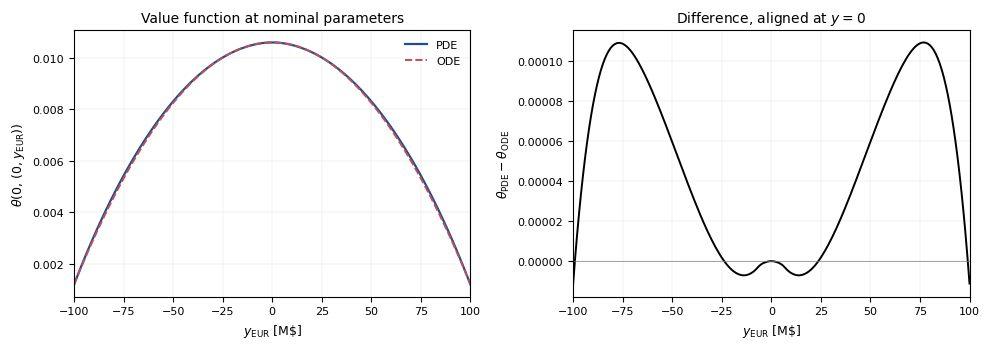

Max |theta_PDE - theta_ODE| in [-100, 100]: 1.09e-04
Max relative diff: 1.03e-02


In [19]:
# Value function profile along y_EUR at y_USD = 0 (nominal parameters)
theta_nom = oat_data['nominal']['theta_0']
y_grid = np.arange(-Y_MAX, Y_MAX + DY, DY)
n_grid = len(y_grid)
idx0 = n_grid // 2

mp_nom = build_modified_params_2ccy(NOMINAL)
res_nom = run_multicurrency_mm(mp_nom, n_steps=500)
A0, B0 = res_nom.A0, res_nom.B0

# ODE profile up to the additive constant C(0), then align with the PDE at y=0
theta_ode_profile = np.array([
    -(np.array([0.0, y_eur]) @ A0 @ np.array([0.0, y_eur])) - (B0 @ np.array([0.0, y_eur]))
    for y_eur in y_grid
])
theta_pde_profile = theta_nom[idx0, :]
theta_ode_profile += theta_pde_profile[idx0] - theta_ode_profile[idx0]
diff = theta_pde_profile - theta_ode_profile

# Crop to region of interest so matplotlib autoscaling is not distorted by
# boundary artifacts in the 50 M$ buffer zone
roi = (y_grid >= -100) & (y_grid <= 100)
y_plot = y_grid[roi]

pde_color = "#1f4e8c"
ode_color = "#c44e52"
plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))

ax1.plot(y_plot, theta_pde_profile[roi], color=pde_color, linewidth=1.6, label="PDE")
ax1.plot(y_plot, theta_ode_profile[roi], color=ode_color, linewidth=1.4, linestyle="--", label="ODE")
ax1.set_xlabel(r"$y_{\mathrm{EUR}}$ [M\$]")
ax1.set_ylabel(r"$\theta(0,\,(0, y_{\mathrm{EUR}}))$")
ax1.set_title("Value function at nominal parameters")
ax1.set_xlim(-100, 100)
ax1.grid(True, linewidth=0.3, alpha=0.4)
ax1.legend(frameon=False)

ax2.plot(y_plot, diff[roi], color="black", linewidth=1.4)
ax2.axhline(0, color="grey", linewidth=0.5)
ax2.set_xlabel(r"$y_{\mathrm{EUR}}$ [M\$]")
ax2.set_ylabel(r"$\theta_{\mathrm{PDE}} - \theta_{\mathrm{ODE}}$")
ax2.set_title(r"Difference, aligned at $y=0$")
ax2.set_xlim(-100, 100)
ax2.grid(True, linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.savefig("report/figures/fig_pde_theta_profile.pdf", bbox_inches="tight")
plt.show()

print(f"Max |theta_PDE - theta_ODE| in [-100, 100]: {np.max(np.abs(diff[roi])):.2e}")
print(f"Max relative diff: {np.max(np.abs(diff[roi])) / np.max(np.abs(theta_pde_profile[roi])):.2e}")

### Policy profiles (markup and hedge rate) at nominal parameters

Compare the PDE- and ODE-derived optimal policies along the EUR inventory axis at $y_{\mathrm{USD}} = 0$:
tier-1 markup $\delta^*$ for a 1 M\$ trade, and EUR/USD hedge rate $\xi^*$.
Errors are expected to concentrate at large $|y_{\mathrm{EUR}}|$, which is the geometric form
of the quadratic-Hamiltonian approximation breaking down at large momentum.

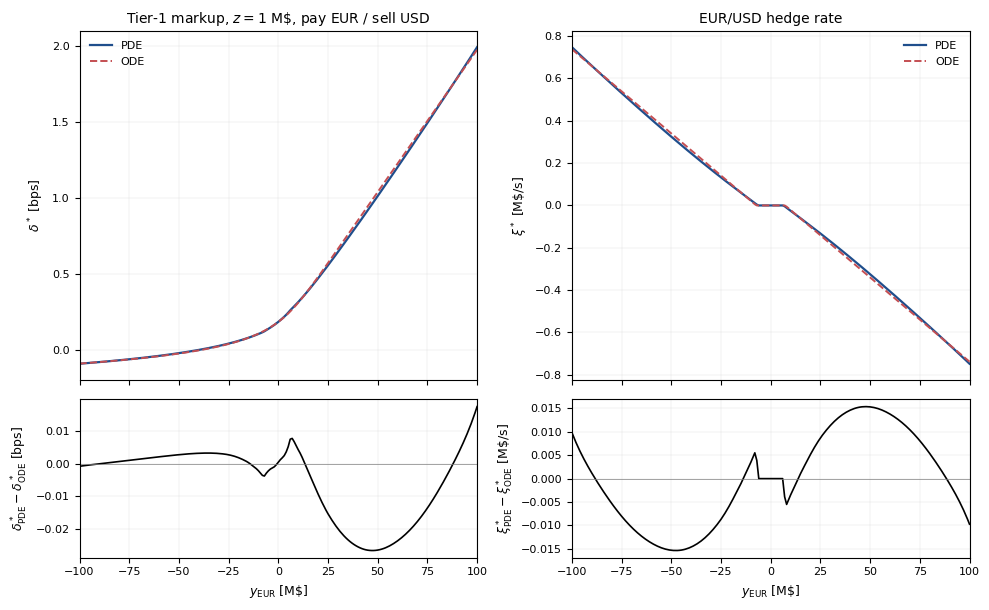

In [20]:
from src.hamiltonian import H_logistic
from src.model import BP, DAY_SECONDS

# Nominal params reused from the previous cell (theta_nom, mp_nom, res_nom, y_grid, idx0, roi, y_plot)
pair = mp_nom.pairs[("EUR", "USD")]
alpha_1 = pair.tiers[0].alpha
beta_1 = pair.tiers[0].beta
psi, eta = pair.psi, pair.eta
k_usd = mp_nom.k.get("USD", 0.0)
k_eur = mp_nom.k.get("EUR", 0.0)

# PDE markup (tier 1, z=1, pay EUR / sell USD): d = e_EUR - e_USD
# p(y_EUR) at y_USD=0  =  theta[idx0, j] - theta[idx0-1, j+1]
p_pde = np.full(n_grid, np.nan)
for j in range(n_grid):
    if j + 1 < n_grid and idx0 - 1 >= 0:
        p_pde[j] = theta_nom[idx0, j] - theta_nom[idx0 - 1, j + 1]
_, delta_pde, _ = H_logistic(p_pde, alpha_1, beta_1)
delta_pde_bps = delta_pde / BP
delta_ode_bps = np.array([
    res_nom.markup(0, "EUR", "USD", 1.0, np.array([0.0, y_eur])) / BP
    for y_eur in y_grid
])

# PDE hedge rate: central-difference gradients at y_USD=0 along y_EUR
grad_usd = np.full(n_grid, np.nan)
grad_eur = np.full(n_grid, np.nan)
for j in range(n_grid):
    grad_usd[j] = (theta_nom[idx0 + 1, j] - theta_nom[idx0 - 1, j]) / (2.0 * DY)
    if 0 < j < n_grid - 1:
        grad_eur[j] = (theta_nom[idx0, j + 1] - theta_nom[idx0, j - 1]) / (2.0 * DY)

xi_pde_per_day = np.full(n_grid, np.nan)
for j in range(n_grid):
    y_eur = y_grid[j]
    q = grad_eur[j] - grad_usd[j] + k_eur * y_eur * (1.0 + grad_eur[j])
    if np.isfinite(q):
        xi_pde_per_day[j] = np.sign(q) * max(abs(q) - psi, 0.0) / (2.0 * eta)

# Convert to per-second to match the convention used in the ODE chapter
xi_pde_per_s = xi_pde_per_day / DAY_SECONDS
xi_ode_per_s = np.array([
    res_nom.hedge_rate("EUR", "USD", np.array([0.0, y_eur])) / DAY_SECONDS
    for y_eur in y_grid
])

# Restrict to the region of interest (the buffer zone would distort autoscaling)
delta_pde_r = delta_pde_bps[roi]
delta_ode_r = delta_ode_bps[roi]
xi_pde_r = xi_pde_per_s[roi]
xi_ode_r = xi_ode_per_s[roi]
delta_err = delta_pde_r - delta_ode_r
xi_err = xi_pde_r - xi_ode_r

fig, axes = plt.subplots(2, 2, figsize=(10, 6.2), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})

ax = axes[0, 0]
ax.plot(y_plot, delta_pde_r, color=pde_color, linewidth=1.6, label="PDE")
ax.plot(y_plot, delta_ode_r, color=ode_color, linewidth=1.4, linestyle="--", label="ODE")
ax.set_ylabel(r"$\delta^*$ [bps]")
ax.set_title(r"Tier-1 markup, $z = 1$ M\$, pay EUR / sell USD")
ax.legend(frameon=False)
ax.grid(True, linewidth=0.3, alpha=0.4)

ax = axes[0, 1]
ax.plot(y_plot, xi_pde_r, color=pde_color, linewidth=1.6, label="PDE")
ax.plot(y_plot, xi_ode_r, color=ode_color, linewidth=1.4, linestyle="--", label="ODE")
ax.set_ylabel(r"$\xi^*$ [M\$/s]")
ax.set_title(r"EUR/USD hedge rate")
ax.legend(frameon=False)
ax.grid(True, linewidth=0.3, alpha=0.4)

ax = axes[1, 0]
ax.plot(y_plot, delta_err, color="black", linewidth=1.2)
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel(r"$\delta^*_{\mathrm{PDE}} - \delta^*_{\mathrm{ODE}}$ [bps]")
ax.set_xlabel(r"$y_{\mathrm{EUR}}$ [M\$]")
ax.grid(True, linewidth=0.3, alpha=0.4)

ax = axes[1, 1]
ax.plot(y_plot, xi_err, color="black", linewidth=1.2)
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel(r"$\xi^*_{\mathrm{PDE}} - \xi^*_{\mathrm{ODE}}$ [M\$/s]")
ax.set_xlabel(r"$y_{\mathrm{EUR}}$ [M\$]")
ax.grid(True, linewidth=0.3, alpha=0.4)

for ax in axes.flat:
    ax.set_xlim(-100, 100)

plt.tight_layout()
plt.savefig("report/figures/fig_pde_policy_profiles.pdf", bbox_inches="tight")
plt.show()

### Hessian A comparison

In [21]:
# Extract PDE Hessian at y=0 via central finite differences
# theta_ansatz = -y^T A y - y^T B - C
# d^2 theta / dy_EUR^2 = -2 * A[EUR, EUR]
# So A_PDE[EUR,EUR] = -(1/2) * d^2 theta / dy_EUR^2 at y=0

theta_nom = oat_data['nominal']['theta_0']
idx0 = len(y_grid) // 2

# Second derivative along EUR axis at (y_USD=0, y_EUR=0)
d2_eur = (theta_nom[idx0, idx0+1] - 2*theta_nom[idx0, idx0] + theta_nom[idx0, idx0-1]) / DY**2
A_pde_eur_eur = -0.5 * d2_eur

# ODE A matrix
A_ode = res_nom.A0
A_ode_eur_eur = A_ode[1, 1]  # EUR is index 1

print("Riccati matrix A comparison at y=0:")
print(f"  A_ODE[EUR,EUR] = {A_ode_eur_eur:.6e}")
print(f"  A_PDE[EUR,EUR] = {A_pde_eur_eur:.6e}")
print(f"  Relative diff  = {abs(A_ode_eur_eur - A_pde_eur_eur) / abs(A_pde_eur_eur):.2e}")

# Also extract B from first derivative at y=0
# d theta / dy_EUR at y=0 = -(2*A*y + B)[EUR] = -B[EUR] (since y=0)
d1_eur = (theta_nom[idx0, idx0+1] - theta_nom[idx0, idx0-1]) / (2*DY)
B_pde_eur = -d1_eur
B_ode_eur = res_nom.B0[1]

print(f"\n  B_ODE[EUR]     = {B_ode_eur:.6e}")
print(f"  B_PDE[EUR]     = {B_pde_eur:.6e}")
print(f"  Relative diff  = {abs(B_ode_eur - B_pde_eur) / (abs(B_pde_eur) + 1e-30):.2e}")

Riccati matrix A comparison at y=0:
  A_ODE[EUR,EUR] = 9.378559e-07
  A_PDE[EUR,EUR] = 1.009554e-06
  Relative diff  = 7.10e-02

  B_ODE[EUR]     = 0.000000e+00
  B_PDE[EUR]     = -2.317271e-11
  Relative diff  = 1.00e+00


### Bridging d=2 to d=3

The sensitivity analysis uses 3 currencies (USD, EUR, GBP) but the PDE
can only validate 2 currencies. The theoretical argument: the ODE error
is per-pair (quadratic Hamiltonian approximation), while cross-pair
interactions are exact in the Riccati matrix algebra.

Below we provide empirical support:
1. Inspect the 3-currency Riccati matrix A(0) -- how large are cross-pair entries?
2. Compare EUR/USD QoIs from 2-currency vs 3-currency ODE -- how much does adding GBP change results?

In [22]:
from src import build_paper_example_params, restrict_currencies, run_multicurrency_mm

# 3-currency ODE at nominal
mp_3ccy = build_paper_example_params()
mp_3ccy_restricted = restrict_currencies(mp_3ccy, ["USD", "EUR", "GBP"])
res_3ccy = run_multicurrency_mm(mp_3ccy_restricted, n_steps=500)

# 2-currency ODE at nominal (already computed)
res_2ccy = res_nom

print("=== Riccati matrix A(0) -- 3-currency model ===")
ccy = mp_3ccy_restricted.currencies  # ["USD", "EUR", "GBP"]
print(f"Currencies: {ccy}")
print(f"\nA(0) matrix:")
for i, ci in enumerate(ccy):
    row = "  ".join(f"{res_3ccy.A0[i,j]:10.4e}" for j in range(3))
    print(f"  {ci}: {row}")

# Cross-pair coupling ratio
i_eur = ccy.index("EUR")
i_gbp = ccy.index("GBP")
A_diag_eur = res_3ccy.A0[i_eur, i_eur]
A_cross = res_3ccy.A0[i_eur, i_gbp]
print(f"\n|A[EUR,GBP]| / A[EUR,EUR] = {abs(A_cross) / abs(A_diag_eur):.4f}")
print(f"  -> Cross-pair coupling is {abs(A_cross)/abs(A_diag_eur)*100:.1f}% of diagonal")

# Compare EUR/USD QoIs: 2-ccy vs 3-ccy
print("\n=== EUR/USD QoIs: 2-ccy vs 3-ccy ODE ===")
y_flat_2 = np.zeros(2)
y_flat_3 = np.zeros(3)
y_long_2 = np.array([0.0, 10.0])
y_long_3 = np.array([0.0, 10.0, 0.0])

comparisons = [
    ("delta*(y=0) tier1 [bps]",
     res_2ccy.markup(0, "EUR", "USD", 1.0, y_flat_2) / BP,
     res_3ccy.markup(0, "EUR", "USD", 1.0, y_flat_3) / BP),
    ("delta*(y=0) tier2 [bps]",
     res_2ccy.markup(1, "EUR", "USD", 1.0, y_flat_2) / BP,
     res_3ccy.markup(1, "EUR", "USD", 1.0, y_flat_3) / BP),
    ("inv skew [bps]",
     (res_2ccy.markup(0, "EUR", "USD", 1.0, y_long_2) - res_2ccy.markup(0, "EUR", "USD", 1.0, y_flat_2)) / BP,
     (res_3ccy.markup(0, "EUR", "USD", 1.0, y_long_3) - res_3ccy.markup(0, "EUR", "USD", 1.0, y_flat_3)) / BP),
    ("hedge rate [M$/day]",
     res_2ccy.hedge_rate("EUR", "USD", y_long_2),
     res_3ccy.hedge_rate("EUR", "USD", y_long_3)),
]

print(f"  {'QoI':>25s}  {'2-ccy':>12s}  {'3-ccy':>12s}  {'rel diff':>10s}")
for label, v2, v3 in comparisons:
    rd = abs(v2 - v3) / (abs(v3) + 1e-30)
    print(f"  {label:>25s}  {v2:12.6f}  {v3:12.6f}  {rd:10.2e}")

=== Riccati matrix A(0) -- 3-currency model ===
Currencies: ['USD', 'EUR', 'GBP']

A(0) matrix:
  USD: 0.0000e+00  0.0000e+00  0.0000e+00
  EUR: 0.0000e+00  9.0683e-07  3.9667e-07
  GBP: 0.0000e+00  3.9667e-07  1.3436e-06

|A[EUR,GBP]| / A[EUR,EUR] = 0.4374
  -> Cross-pair coupling is 43.7% of diagonal

=== EUR/USD QoIs: 2-ccy vs 3-ccy ODE ===
                        QoI         2-ccy         3-ccy    rel diff
    delta*(y=0) tier1 [bps]      0.182200      0.182037    8.96e-04
    delta*(y=0) tier2 [bps]      0.392670      0.392439    5.89e-04
             inv skew [bps]      0.126116      0.120990    4.24e-02
        hedge rate [M$/day]  -1878.606316  -1568.371522    1.98e-01


### LHS results: multi-parameter error distribution

Relative error comparison: OAT vs LHS
                 QoI     OAT max     LHS max  LHS median     LHS 95%
    tier_spread_diff    1.59e-03    4.24e-03    5.09e-04    3.06e-03
        own_inv_skew    1.53e-01    1.52e-01    7.65e-02    1.49e-01
          hedge_rate    7.61e-01    1.00e+00    1.89e-01    1.00e+00
         net_revenue    6.55e-01    7.06e-01    7.88e-02    5.23e-01
      neutral_spread    5.31e-03    9.56e-03    1.68e-03    7.67e-03


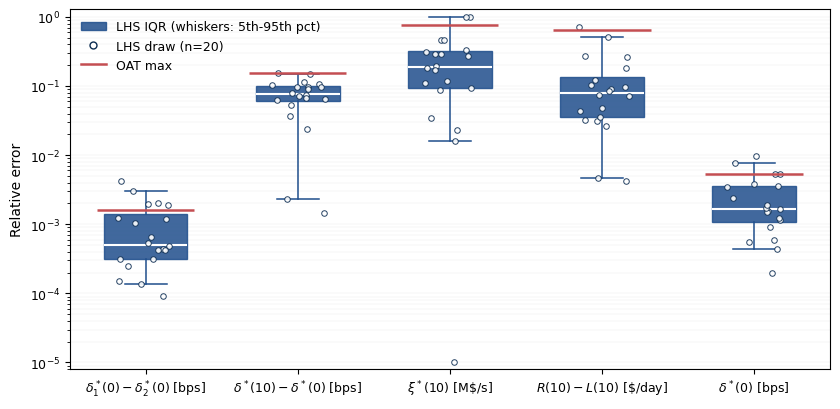

In [23]:
# LHS relative-error distribution per QoI.
# Box = IQR, whiskers = 5th-95th pct, dots = individual draws.
# Red segments mark the OAT maximum per QoI.
# Uses shared helpers (PANEL_TITLES, NAVY, CORAL) from the sensitivity
# ranking cell above.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def _rel_err(data):
    r = np.zeros((len(data), N_QOIS))
    for i, name in enumerate(sorted(data)):
        ode, pde = data[name]["ode_qois"], data[name]["pde_qois"]
        r[i] = np.abs(ode - pde) / (np.abs(pde) + 1e-30)
    return r

lhs_r = _rel_err(lhs_data)
oat_r = _rel_err(oat_data)
oat_max = oat_r.max(axis=0)

# Summary table
print("Relative error comparison: OAT vs LHS")
print(f"{'QoI':>20s}  {'OAT max':>10s}  {'LHS max':>10s}  {'LHS median':>10s}  {'LHS 95%':>10s}")
for q in range(N_QOIS):
    print(f"{QOI_NAMES[q]:>20s}  {oat_r[:, q].max():10.2e}  {lhs_r[:, q].max():10.2e}  "
          f"{np.median(lhs_r[:, q]):10.2e}  {np.percentile(lhs_r[:, q], 95):10.2e}")

plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
})

fig, ax = plt.subplots(figsize=(8.5, 4.2))

floor = 1e-5
lhs_plot = np.where(lhs_r > 0, lhs_r, floor)
positions = np.arange(N_QOIS)

ax.boxplot(
    [lhs_plot[:, q] for q in range(N_QOIS)],
    positions=positions, widths=0.55,
    whis=(5, 95), showfliers=False, patch_artist=True,
    medianprops={"color": "white", "linewidth": 1.5},
    boxprops={"facecolor": NAVY, "edgecolor": NAVY, "alpha": 0.85},
    whiskerprops={"color": NAVY, "linewidth": 1.1},
    capprops={"color": NAVY, "linewidth": 1.1},
)

rng = np.random.default_rng(0)
for q in range(N_QOIS):
    x = positions[q] + rng.uniform(-0.18, 0.18, size=lhs_plot.shape[0])
    ax.scatter(x, lhs_plot[:, q], s=16, color="white",
               edgecolors="#0d2d52", linewidths=0.7, alpha=0.9, zorder=4)
for q in range(N_QOIS):
    ax.hlines(oat_max[q], positions[q] - 0.32, positions[q] + 0.32,
              colors=CORAL, linewidth=1.8, zorder=5)

handles = [
    Patch(facecolor=NAVY, edgecolor=NAVY, alpha=0.85,
          label="LHS IQR (whiskers: 5th-95th pct)"),
    Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white",
           markeredgecolor="#0d2d52", markersize=5,
           label=f"LHS draw (n={lhs_r.shape[0]})"),
    Line2D([0], [0], color=CORAL, linewidth=1.8, label="OAT max"),
]
ax.legend(handles=handles, loc="upper left", frameon=False)

ax.set_yscale("log")
ax.set_ylim(floor * 0.8, 1.3)
ax.set_xticks(positions)
ax.set_xticklabels([PANEL_TITLES[QOI_NAMES[q]] for q in range(N_QOIS)], fontsize=9)
ax.set_ylabel("Relative error")
ax.grid(True, which="both", axis="y", linewidth=0.3, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("report/figures/fig_pde_lhs_errors.pdf", bbox_inches="tight")
plt.show()